# Assignment 4: Predicting PM2.5 air quality from meteorology with random forests

Fine particulate matter (**PM2.5**) is the air pollutant responsible for the largest
global health burden. It penetrates deep into the lungs and enters the bloodstream, and
long-term exposure is linked to cardiovascular and respiratory disease. Regulatory networks
measure it directly, but direct measurement is expensive and sparse, so a recurring question
in air quality science is how much of the day-to-day variation can be explained by
**meteorology** and by other, more cheaply measured pollutants.

That is the question you will attack here, with decision trees and random forests. Pollution
concentrations are set by the balance between emissions and the atmosphere's ability to
disperse them, and the dispersion side is meteorological: wind ventilates, a deep mixing
layer dilutes, humidity drives secondary particle formation, temperature controls both
chemistry and the stability of the boundary layer. These relationships are strongly
**nonlinear** and full of **interactions**: which is exactly what trees are good at and
what a linear model handles badly.

You will use **real measurements from the US EPA Air Quality System** for 2023, the year
of the record Canadian wildfire season. Every number in this notebook is an instrument
reading from a regulatory monitor.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 4. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


In [1]:
import io
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the data

EPA publishes pre-generated annual files, one per measured parameter, with no API key
required. We need six of them: PM2.5 (our target), plus temperature, wind, relative
humidity, ozone and nitrogen dioxide as predictors. Together they are about 27 MB.

Different parameters are measured at different monitoring sites, so the files cannot be
joined at site level without discarding most of the data. We aggregate each one to a
**county-day** mean and join on that. The resulting unit of analysis is "one county on one
day".

In [2]:
BASE = "https://aqs.epa.gov/aqsweb/airdata/"

def load_epa(filename, usecols):
    """Download one EPA annual file and return it as a dataframe."""
    with urllib.request.urlopen(BASE + filename + ".zip") as resp:
        archive = zipfile.ZipFile(io.BytesIO(resp.read()))
    df = pd.read_csv(archive.open(archive.namelist()[0]), usecols=usecols, low_memory=False)
    df["Date Local"] = pd.to_datetime(df["Date Local"])
    return df

KEY = ["State Code", "County Code", "Date Local"]

# PM2.5 -- the target. We keep the AQI column too; it is the official index value.
pm = load_epa("daily_88101_2023",
              KEY + ["Arithmetic Mean", "AQI", "Latitude", "Longitude",
                     "State Name", "County Name"])
print(f"{len(pm):,} PM2.5 site-days")

data = (pm.groupby(KEY)
          .agg(pm25=("Arithmetic Mean", "mean"), AQI=("AQI", "max"),
               lat=("Latitude", "mean"), lon=("Longitude", "mean"),
               state=("State Name", "first"), county=("County Name", "first"))
          .reset_index())
print(f"{len(data):,} PM2.5 county-days")

# Predictors, each aggregated to the county-day mean and joined on.
for filename, column in [("daily_TEMP_2023", "temp"),
                         ("daily_WIND_2023", "wind"),
                         ("daily_RH_DP_2023", "rh"),
                         ("daily_44201_2023", "o3"),
                         ("daily_42602_2023", "no2")]:
    d = load_epa(filename, KEY + ["Arithmetic Mean"])
    d = d.groupby(KEY)["Arithmetic Mean"].mean().reset_index().rename(
        columns={"Arithmetic Mean": column})
    data = data.merge(d, on=KEY, how="inner")
    print(f"  after joining {column:<5} {len(data):>7,} rows")

data["month"] = data["Date Local"].dt.month
data.head()

847,162 PM2.5 site-days
203,450 PM2.5 county-days


  after joining temp  133,641 rows


  after joining wind   81,482 rows


  after joining rh     55,448 rows


  after joining o3     48,113 rows


  after joining no2    31,713 rows


,State Code,County Code,Date Local,pm25,AQI,lat,lon,state,county,temp,wind,rh,o3,no2,month
0,1,73,2023-01-01,9.877084,53.0,33.545278,-86.549167,Alabama,Jefferson,71.199004,64.037500,68.562500,0.031588,6.466667,1
1,1,73,2023-01-02,7.985417,47.0,33.545278,-86.549167,Alabama,Jefferson,71.762500,69.865625,77.291667,0.019824,5.039583,1
2,1,73,2023-01-03,5.326042,32.0,33.545278,-86.549167,Alabama,Jefferson,74.531521,69.900000,84.375000,0.021471,5.462500,1
3,1,73,2023-01-04,4.035227,31.0,33.537574,-86.666139,Alabama,Jefferson,68.338750,96.290625,68.312500,0.017235,10.393750,1
4,1,73,2023-01-05,3.582292,22.0,33.545278,-86.549167,Alabama,Jefferson,55.845833,109.393750,51.929167,0.030412,11.837311,1


The columns are:

| Column | Meaning | Units |
| --- | --- | --- |
| `pm25` | daily mean PM2.5: **the regression target** | µg/m³ |
| `AQI` | official Air Quality Index for PM2.5 | index |
| `temp` | daily mean temperature | °F |
| `wind` | daily mean wind speed | knots |
| `rh` | daily mean relative humidity | % |
| `o3` | daily mean ozone | ppm |
| `no2` | daily mean nitrogen dioxide | ppb |
| `lat`, `lon` | county monitor location | degrees |
| `month` | calendar month | 1–12 |

```{admonition} A note on what this model can and cannot be
:class: note
Ozone and NO2 are *pollutants*, not meteorology. They are included because they carry
information about the state of the atmosphere and about local emissions, and because they
are measured on the same network. But be careful about what that means: a model using NO2
to predict PM2.5 is not a physical model of particle formation, it is exploiting the fact
that both respond to traffic emissions and to the same dispersion conditions. Keep that in
mind when you interpret the feature importances in Part 5.
```

## Part 1: Data exploration

1. How many county-days are in the merged dataset, what date range does it cover, and how many distinct states are represented?

In [3]:
print(f"county-days: {len(data):,}")
print(f"date range:  {data['Date Local'].min().date()} to {data['Date Local'].max().date()}")
print(f"states:      {data['state'].nunique()}")
print(f"counties:    {data.groupby(['State Code','County Code']).ngroups:,}")
print()
print("ten best-represented counties:")
print(data.groupby(["state", "county"]).size().sort_values(ascending=False).head(10))

# The merge is restrictive: it keeps only county-days where PM2.5, temperature, wind,
# humidity, ozone AND nitrogen dioxide were all measured. NO2 is the binding constraint --
# it is monitored at far fewer sites than PM2.5, mostly in urban areas. So this dataset is
# not a random sample of US county-days; it is biased towards well-instrumented urban
# counties. Worth remembering before generalizing any conclusion to rural air quality.

county-days: 31,713
date range:  2023-01-01 to 2023-12-31
states:      41
counties:    100

ten best-represented counties:
state           county        
Ohio            Hamilton          365
North Carolina  Mecklenburg       365
California      Ventura           365
Indiana         Marion            365
Wyoming         Fremont           365
California      Stanislaus        365
Missouri        St. Louis City    365
Texas           Harris            365
                Tarrant           365
California      San Diego         365
dtype: int64


2. Check whether there are any NaNs in the dataframe. If there are, say which columns they are in and drop those rows.

In [4]:
print("NaNs per column:")
print(data.isna().sum())

before = len(data)
data = data.dropna(subset=["pm25", "AQI", "temp", "wind", "rh", "o3", "no2"]).reset_index(drop=True)
print()
print(f"dropped {before - len(data)} rows with missing values; {len(data):,} remain")

NaNs per column:
State Code       0
County Code      0
Date Local       0
pm25             0
AQI            158
lat              0
lon              0
state            0
county           0
temp             0
wind             0
rh               0
o3               0
no2              0
month            0
dtype: int64

dropped 158 rows with missing values; 31,555 remain


3. Make a histogram of each of the numerical variables. Comment on the shape of the `pm25` distribution in particular, is it symmetric?

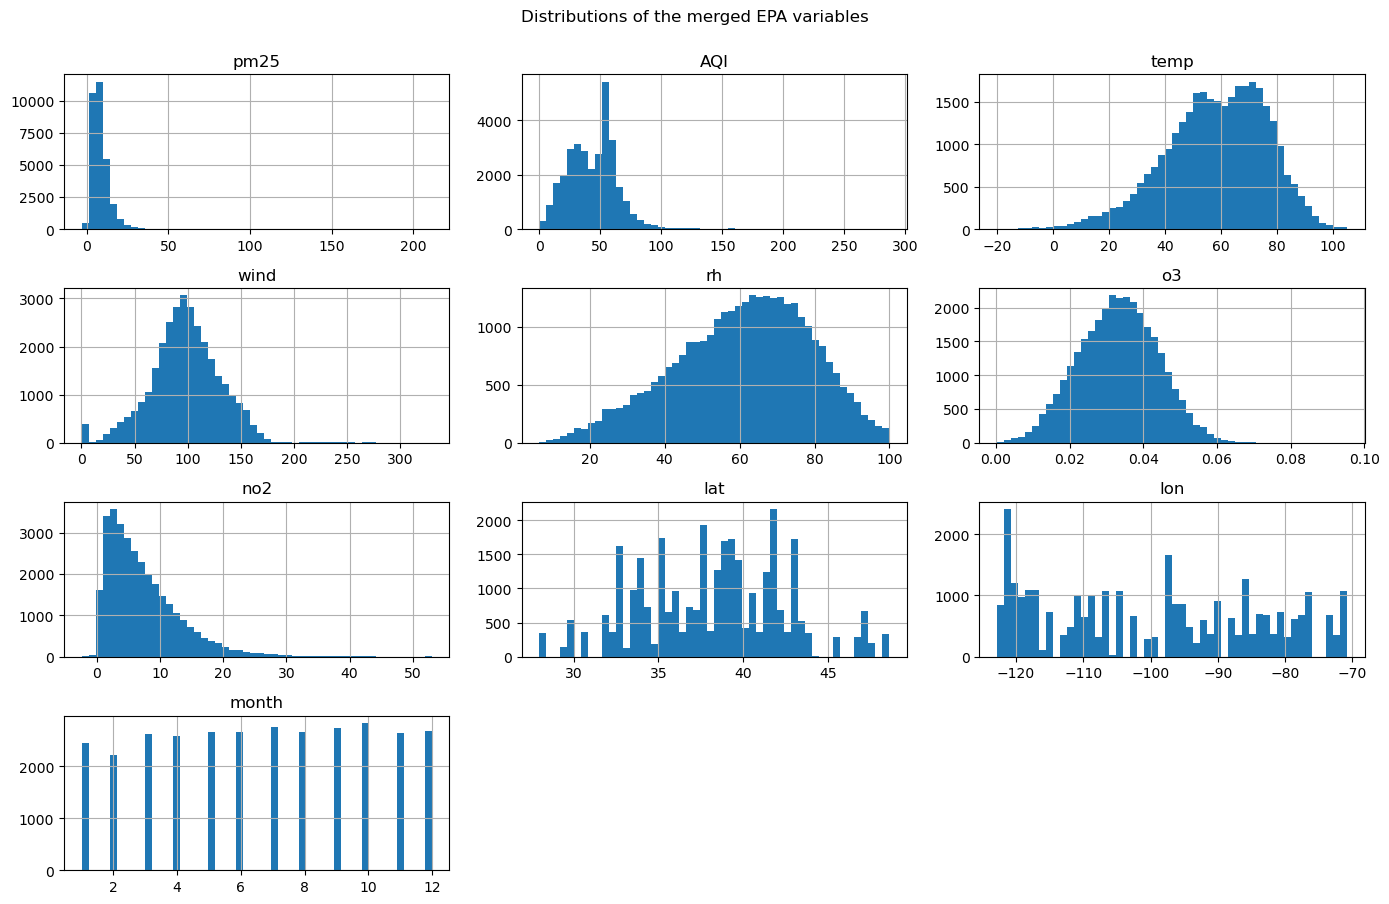

        mean    std     min    50%     max
pm25    8.24   6.95   -3.22   6.84  211.55
AQI    44.30  21.07    0.00  45.00  287.00
temp   58.30  18.09  -20.12  59.73  105.00
wind   97.85  33.07    0.15  97.32  329.63
rh     61.02  18.02    6.54  62.62  100.00
o3      0.03   0.01    0.00   0.03    0.10
no2     7.18   5.62   -2.40   5.79   53.02
lat    38.25   4.25   27.96  38.65   48.64
lon   -99.59  16.11 -122.88 -97.53  -70.75
month   6.64   3.41    1.00   7.00   12.00


In [5]:
numeric = data[["pm25", "AQI", "temp", "wind", "rh", "o3", "no2", "lat", "lon", "month"]]
numeric.hist(figsize=(14, 9), bins=50)
plt.suptitle("Distributions of the merged EPA variables", y=1.0)
plt.tight_layout()
plt.show()

print(numeric.describe().T[["mean", "std", "min", "50%", "max"]].round(2))

# pm25 is strongly RIGHT-SKEWED and emphatically not symmetric: the median sits well below
# the mean and the distribution has a long thin tail running to very high values. That tail
# is where the interesting days live -- wildfire smoke, winter inversions, dust -- and it is
# a small fraction of the record.
#
# The physical reason is the one seen in Assignment 10: concentrations are produced by
# multiplicative processes (emissions divided by a mixing depth, ventilated by wind), and a
# product of many factors is log-normal in the same way a sum of many factors is normal.
# Episodic sources then stretch the right tail further.
#
# This matters for what follows. A squared-error loss on a right-skewed target is dominated
# by the few extreme days, and R^2 will be driven by whether the model captures them.

4. There are two targets. The numerical one is `pm25`, the daily mean concentration. The
categorical one is the **AQI category**, the band the EPA reports to the public, which is
derived from the AQI value by these breakpoints:

| Category | AQI range | Label |
| --- | --- | --- |
| 0 | 0–50 | Good |
| 1 | 51–100 | Moderate |
| 2 | 101–150 | Unhealthy for Sensitive Groups |
| 3 | 151–200 | Unhealthy |
| 4 | 201+ | Very Unhealthy or worse |

Create a NumPy array `y_regression` containing `pm25`, and a NumPy array
`y_classification` containing the AQI category computed from the `AQI` column.

In [6]:
y_regression = data["pm25"].values

# AQI category from the official EPA breakpoints.
aqi = data["AQI"].values
y_classification = np.select(
    [aqi <= 50, aqi <= 100, aqi <= 150, aqi <= 200],
    [0, 1, 2, 3], default=4)

print("y_regression:    ", y_regression.shape, y_regression.dtype)
print(f"  range {y_regression.min():.1f} to {y_regression.max():.1f} ug/m3")
print("y_classification:", y_classification.shape, y_classification.dtype)
print("  classes present:", np.unique(y_classification))

# A subtlety in how these two targets relate. The AQI is a published piecewise-linear
# function of the 24-hour PM2.5 concentration, so at a single MONITOR the category is a
# deterministic binning of the concentration. That is not quite true of the columns here,
# because the county aggregation used two different rules: AQI was aggregated with max (the
# county AQI is reported as the worst site) while pm25 was aggregated with mean. So a county
# with one smoky site and three clean ones gets a high category and a middling mean
# concentration, and the class ranges overlap as a result -- you will see this in question 7.
#
# Keep it in mind when comparing Parts 4 and 5: the classifier and the regressor are being
# asked about closely related but not identical quantities.

y_regression:     (31555,) float64
  range -3.2 to 211.5 ug/m3
y_classification: (31555,) int64
  classes present: [0 1 2 3 4]


5. Check how balanced the five classes are. Report the count and the percentage in each.

  0  Good                             18,017  (57.097%)
  1  Moderate                         13,207  (41.854%)
  2  Unhealthy for Sensitive Groups      224  ( 0.710%)
  3  Unhealthy                            95  ( 0.301%)
  4  Very Unhealthy+                      12  ( 0.038%)

imbalance ratio (largest / smallest): 1,501x


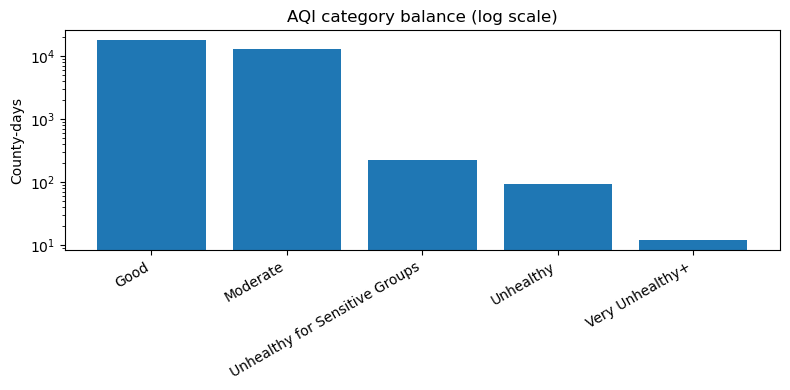

In [7]:
classnames_tmp = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
                  "Unhealthy", "Very Unhealthy+"]
counts = pd.Series(y_classification).value_counts().sort_index()

for cls in range(5):
    n = int(counts.get(cls, 0))
    print(f"  {cls}  {classnames_tmp[cls]:<32} {n:>6,}  ({100 * n / len(y_classification):6.3f}%)")

print()
print(f"imbalance ratio (largest / smallest): "
      f"{counts.max() / counts[counts > 0].min():,.0f}x")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(5), [counts.get(c, 0) for c in range(5)])
ax.set_xticks(range(5))
ax.set_xticklabels(classnames_tmp, rotation=30, ha="right")
ax.set_ylabel("County-days")
ax.set_yscale("log")
ax.set_title("AQI category balance (log scale)")
plt.tight_layout()
plt.show()

# Severely imbalanced, and note this is REAL imbalance rather than an artefact: unhealthy
# air is genuinely rare in the US on a county-day basis. Roughly 99% of the record is Good
# or Moderate. The three unhealthy categories together account for about 1% of days -- and
# those are precisely the days the public and regulators care about.
#
# A log y-axis is essential here; on a linear scale the three rare classes are invisible.

6. Create a NumPy array called `features` containing these eight predictors:
   - temp
   - wind
   - rh
   - o3
   - no2
   - month
   - lat
   - lon

In [8]:
feature_cols = ["temp", "wind", "rh", "o3", "no2", "month", "lat", "lon"]
features = data[feature_cols].values

print("features:", features.shape)
print("columns:", feature_cols)

features: (31555, 8)
columns: ['temp', 'wind', 'rh', 'o3', 'no2', 'month', 'lat', 'lon']


## Part 2: Preprocessing

7. Create two Python lists: `classnames`, holding the five category labels in the order
given in question 4, and `featurenames`, holding the eight feature names in the order you
built them.

In [9]:
classnames = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
              "Unhealthy", "Very Unhealthy+"]
featurenames = feature_cols

print("classnames:  ", classnames)
print("featurenames:", featurenames)

# Confirm the ordering really is monotone in concentration -- class 0 should hold the
# cleanest days and class 4 the dirtiest.
print()
print("median PM2.5 by class:")
for cls in range(5):
    m = y_classification == cls
    if m.sum():
        print(f"  {cls} {classnames[cls]:<32} n={m.sum():>6,}  "
              f"median {np.median(y_regression[m]):6.2f} ug/m3  "
              f"[{y_regression[m].min():.1f} - {y_regression[m].max():.1f}]")

classnames:   ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy+']
featurenames: ['temp', 'wind', 'rh', 'o3', 'no2', 'month', 'lat', 'lon']

median PM2.5 by class:
  0 Good                             n=18,017  median   4.78 ug/m3  [-3.2 - 17.6]
  1 Moderate                         n=13,207  median  10.84 ug/m3  [3.0 - 35.4]
  2 Unhealthy for Sensitive Groups   n=   224  median  34.73 ug/m3  [11.6 - 54.9]
  3 Unhealthy                        n=    95  median  62.80 ug/m3  [20.8 - 114.8]
  4 Very Unhealthy+                  n=    12  median 138.87 ug/m3  [118.0 - 211.5]


8. Use `StandardScaler` to scale the `features` array, and save the result as a NumPy array `X`.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features)

print("X:", X.shape)
print("means after scaling:", np.round(X.mean(axis=0), 6))
print("sds after scaling:  ", np.round(X.std(axis=0), 6))

# Random forests do not need scaled features -- trees split on order, so any monotone
# transform of a single feature leaves the splits unchanged. It is done here because the
# assignment asks for it and because it costs nothing, but do not carry away the idea that
# it was necessary. It would be necessary for a linear model, an SVM or a neural network.
#
# Note also that this scaler is fitted on the WHOLE dataset before splitting, which is the
# leakage pattern Assignment 5 dissects. It is harmless for a forest, but see question 19.

X: (31555, 8)
means after scaling: [-0. -0. -0.  0.  0. -0.  0.  0.]
sds after scaling:   [1. 1. 1. 1. 1. 1. 1. 1.]


## Part 3: Training, validation, and test split

9. Split the data into training, validation and test sets, with 80% for training and 10%
each for validation and testing. Carry both targets through the split. Use
`stratify=` on the classification target so the rare categories are represented in every
split, and explain in a comment why that matters here.

In [11]:
from sklearn.model_selection import train_test_split

(X_train, X_temp,
 y_classification_train, y_classification_temp,
 y_regression_train, y_regression_temp) = train_test_split(
    X, y_classification, y_regression, test_size=0.2, random_state=0,
    stratify=y_classification)

(X_val, X_test,
 y_classification_val, y_classification_test,
 y_regression_val, y_regression_test) = train_test_split(
    X_temp, y_classification_temp, y_regression_temp, test_size=0.5,
    random_state=0, stratify=y_classification_temp)

print(f"{'set':<12} {'X':>16} {'% of total':>11}")
print("-" * 42)
for name, arr in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"{name:<12} {str(arr.shape):>16} {100 * len(arr) / len(X):>10.1f}%")

print()
print("class counts per split:")
for name, yy in [("train", y_classification_train), ("val", y_classification_val),
                 ("test", y_classification_test)]:
    print(f"  {name:<6}", np.bincount(yy, minlength=5))

# WHY stratify MATTERS HERE. The rarest class has around a dozen examples in the whole
# dataset. An unstratified 10% validation split would, quite often, contain NONE of them --
# and then the confusion matrix row for that class is empty, its recall is undefined, and
# the model looks like it has a problem it has not been given a chance to have. Stratifying
# forces each split to hold the same class proportions, so every class is at least
# represented. It cannot manufacture statistical power: with a dozen examples the estimates
# are still extremely noisy.

set                         X  % of total
------------------------------------------
train              (25244, 8)       80.0%
validation          (3155, 8)       10.0%
test                (3156, 8)       10.0%

class counts per split:
  train  [14414 10566   179    76     9]
  val    [1801 1320   22   10    2]
  test   [1802 1321   23    9    1]


## Part 4: Train a random forest classifier

10. Train a `RandomForestClassifier` with 120 estimators and a maximum depth of 10. Set
`class_weight="balanced"`, since the classes are severely imbalanced. Defaults are fine for
the other hyperparameters.

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=120, max_depth=10,
                                class_weight="balanced", random_state=0, n_jobs=-1)
rf_clf.fit(X_train, y_classification_train)

print(f"training accuracy:   {rf_clf.score(X_train, y_classification_train):.4f}")
print(f"validation accuracy: {rf_clf.score(X_val, y_classification_val):.4f}")

# A majority-class baseline for context -- always predict "Good":
baseline = (y_classification_val == 0).mean()
print(f"majority-class baseline: {baseline:.4f}")

training accuracy:   0.8224
validation accuracy: 0.7509
majority-class baseline: 0.5708


11. Plot the confusion matrix for the trained classifier on the **validation** set as a labelled heatmap, using `classnames` on both axes. Also print the classification report.

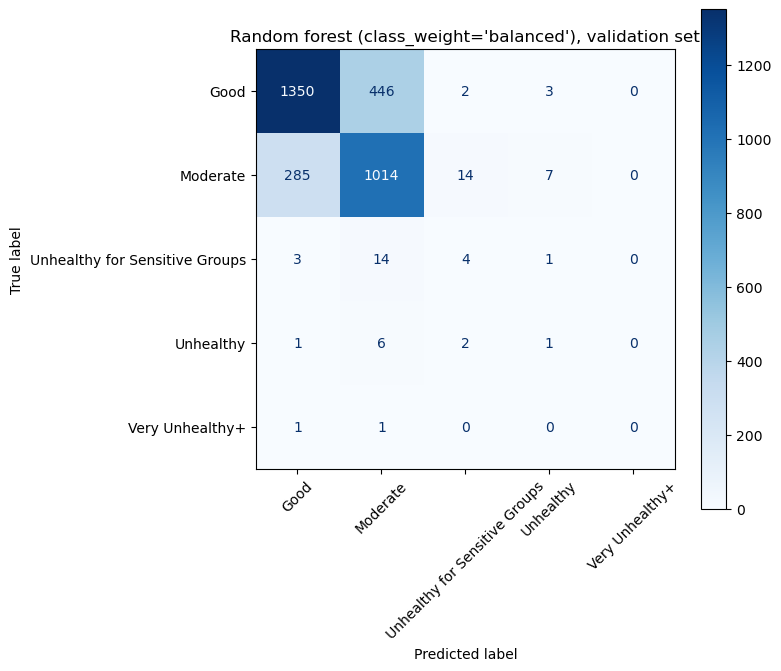

                                precision    recall  f1-score   support

                          Good      0.823     0.750     0.785      1801
                      Moderate      0.685     0.768     0.724      1320
Unhealthy for Sensitive Groups      0.182     0.182     0.182        22
                     Unhealthy      0.083     0.100     0.091        10
               Very Unhealthy+      0.000     0.000     0.000         2

                      accuracy                          0.751      3155
                     macro avg      0.355     0.360     0.356      3155
                  weighted avg      0.758     0.751     0.752      3155



In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_estimator(
    rf_clf, X_val, y_classification_val, display_labels=classnames,
    cmap="Blues", ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title("Random forest (class_weight='balanced'), validation set")
plt.tight_layout()
plt.show()

print(classification_report(y_classification_val, rf_clf.predict(X_val),
                            target_names=classnames, digits=3, zero_division=0))

# Read the diagonal against the ROW totals rather than the raw counts. The two common
# classes are separated reasonably well. The three rare classes are largely missed, and the
# errors that do occur are almost all into an ADJACENT category -- which, since the classes
# are bins of a continuum, means the underlying concentration estimate is not far wrong even
# when the label is.
#
# Note how misleading overall accuracy is here. It sits close to the majority-class
# baseline, and a model that predicted "Good" every single day would score respectably while
# never once warning anybody about unhealthy air.

The confusion matrix will show that the classifier does poorly on the categories that are
barely represented. One standard response is to over-sample the minority classes. Using the
`imbalanced-learn` library, the **SMOTE** algorithm
[(Chawla et al. 2002)](https://arxiv.org/pdf/1106.1813) synthesizes new minority-class
examples by interpolating between real ones.

In [14]:
!pip install imbalanced-learn

In [15]:
from imblearn.over_sampling import SMOTE

In [16]:
X_resampled, y_resampled = SMOTE(k_neighbors=3, random_state=0).fit_resample(
    X_train, y_classification_train)

12. Train a second random forest on `X_resampled` and `y_resampled`, using the same hyperparameters as before.

In [17]:
print(f"before SMOTE: {len(y_classification_train):,} training rows")
print(" ", np.bincount(y_classification_train, minlength=5))
print(f"after SMOTE:  {len(y_resampled):,} training rows")
print(" ", np.bincount(y_resampled, minlength=5))

rf_smote = RandomForestClassifier(n_estimators=120, max_depth=10,
                                  class_weight="balanced", random_state=0, n_jobs=-1)
rf_smote.fit(X_resampled, y_resampled)

print()
print(f"validation accuracy, original: {rf_clf.score(X_val, y_classification_val):.4f}")
print(f"validation accuracy, SMOTE:    {rf_smote.score(X_val, y_classification_val):.4f}")

# SMOTE has equalized the training class counts by interpolating new minority examples
# between each real minority point and its nearest same-class neighbours. Two details worth
# noticing:
#
#  - k_neighbors=3 is set rather than the default 5 because the rarest class has only 9
#    training examples. SMOTE interpolates between a minority point and its k nearest
#    same-class neighbours, so with the default the synthetic points for that class would be
#    drawn from more than half of the entire class at once. Either way the warning stands:
#    when a class is this rare, the "new" examples are interpolations among a handful of real
#    points lying on the segments between them, and they carry very little genuinely new
#    information. SMOTE cannot conjure variety that the data does not contain.
#  - It is applied to the TRAINING set only. The validation set must keep the real class
#    distribution, or the score would describe a world that does not exist.

before SMOTE: 25,244 training rows
  [14414 10566   179    76     9]
after SMOTE:  72,070 training rows
  [14414 14414 14414 14414 14414]



validation accuracy, original: 0.7509
validation accuracy, SMOTE:    0.7242


13. Plot the confusion matrix for this second classifier on the validation set, again labelled with `classnames`. Compare it against the first: which classes improved, which got worse, and what happened to overall accuracy?

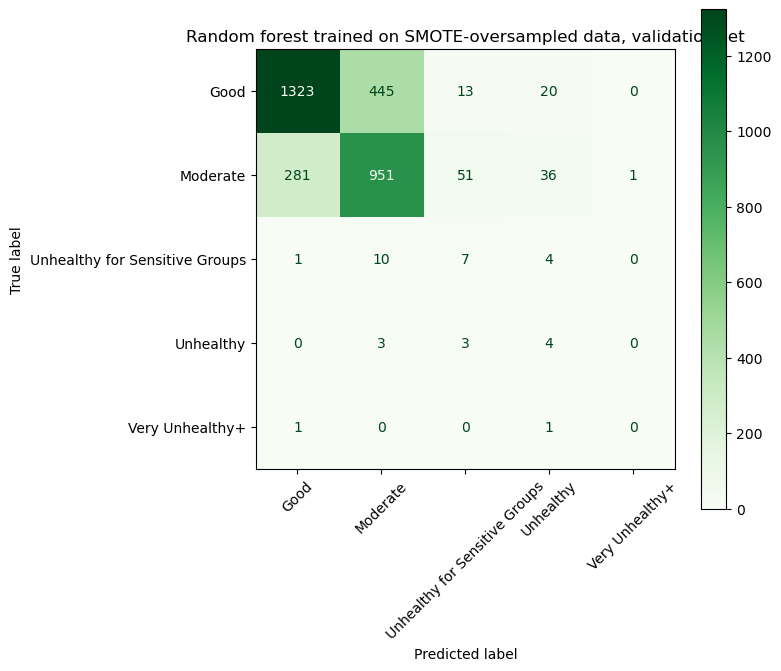

                                precision    recall  f1-score   support

                          Good      0.824     0.735     0.777      1801
                      Moderate      0.675     0.720     0.697      1320
Unhealthy for Sensitive Groups      0.095     0.318     0.146        22
                     Unhealthy      0.062     0.400     0.107        10
               Very Unhealthy+      0.000     0.000     0.000         2

                      accuracy                          0.724      3155
                     macro avg      0.331     0.435     0.345      3155
                  weighted avg      0.753     0.724     0.736      3155

class                             recall before  recall after  precision before  precision after
------------------------------------------------------------------------------------------------
Good                                      0.750         0.735             0.823            0.824
Moderate                                  0.768         0.

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_estimator(
    rf_smote, X_val, y_classification_val, display_labels=classnames,
    cmap="Greens", ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title("Random forest trained on SMOTE-oversampled data, validation set")
plt.tight_layout()
plt.show()

print(classification_report(y_classification_val, rf_smote.predict(X_val),
                            target_names=classnames, digits=3, zero_division=0))

rep_a = classification_report(y_classification_val, rf_clf.predict(X_val),
                              target_names=classnames, output_dict=True, zero_division=0)
rep_b = classification_report(y_classification_val, rf_smote.predict(X_val),
                              target_names=classnames, output_dict=True, zero_division=0)
print(f"{'class':<32} {'recall before':>14} {'recall after':>13} {'precision before':>17} {'precision after':>16}")
print("-" * 96)
for c in classnames:
    print(f"{c:<32} {rep_a[c]['recall']:>14.3f} {rep_b[c]['recall']:>13.3f} "
          f"{rep_a[c]['precision']:>17.3f} {rep_b[c]['precision']:>16.3f}")

# The pattern to look for is the classic oversampling trade: RECALL on the rare classes goes
# up (more genuinely unhealthy days get caught) while PRECISION goes down (the model now
# predicts those classes more freely, so more false alarms), and OVERALL ACCURACY often
# falls because accuracy is dominated by the common classes that oversampling deliberately
# stops privileging.
#
# Which is preferable is a question about consequences, not statistics. For an air quality
# alert, failing to warn on a genuinely unhealthy day is far costlier than a false alarm
# that leads someone to stay indoors unnecessarily. Under that asymmetry the recall gain is
# worth the precision loss -- but say so explicitly rather than picking whichever model has
# the higher accuracy.

## Part 5: Train a random forest regressor

14. Train a `RandomForestRegressor` on the training set using the regression target, with 120 estimators and a maximum depth of 10.

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=120, max_depth=10,
                               random_state=0, n_jobs=-1)
rf_reg.fit(X_train, y_regression_train)

print(f"trained on {X_train.shape[0]:,} samples")
print(f"training R^2: {rf_reg.score(X_train, y_regression_train):.4f}")

trained on 25,244 samples
training R^2: 0.6620


15. Predict PM2.5 for the validation set and compute the coefficient of determination ($R^2$) between the true and predicted values. Also report the RMSE in µg/m³, and plot predicted against observed with a 1:1 line.

validation R^2:  0.3534
validation RMSE: 5.46 ug/m3
  for reference, the target has mean 8.22 and sd 6.79 ug/m3
mean-baseline RMSE: 6.79 ug/m3 (20% improvement)


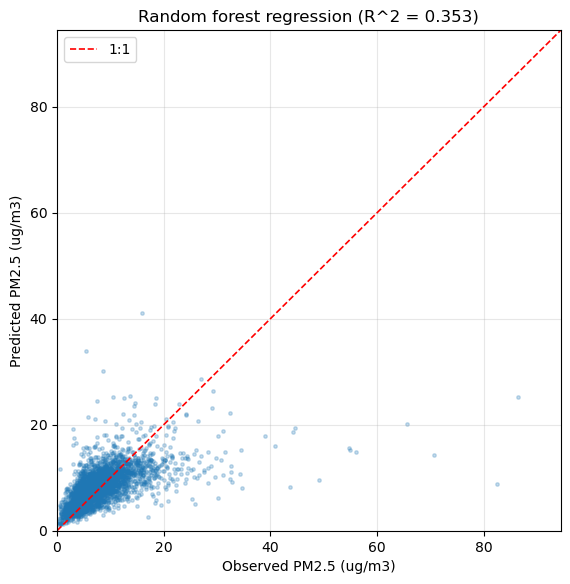

In [20]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = rf_reg.predict(X_val)
r2 = r2_score(y_regression_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_regression_val, y_pred))

print(f"validation R^2:  {r2:.4f}")
print(f"validation RMSE: {rmse:.2f} ug/m3")
print(f"  for reference, the target has mean {y_regression_val.mean():.2f} "
      f"and sd {y_regression_val.std():.2f} ug/m3")

# Baseline: always predict the training mean.
rmse_base = np.sqrt(mean_squared_error(
    y_regression_val, np.full_like(y_regression_val, y_regression_train.mean())))
print(f"mean-baseline RMSE: {rmse_base:.2f} ug/m3 "
      f"({100 * (1 - rmse / rmse_base):.0f}% improvement)")

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(y_regression_val, y_pred, s=6, alpha=0.25)
lims = [0, np.percentile(y_regression_val, 99.9) * 1.1]
ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed PM2.5 (ug/m3)")
ax.set_ylabel("Predicted PM2.5 (ug/m3)")
ax.set_title(f"Random forest regression (R^2 = {r2:.3f})")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# The scatter tells the story that R^2 alone hides: the cloud is well centred at low
# concentrations but the model systematically UNDER-predicts the high days, with the points
# falling below the 1:1 line as observed concentration rises. That is regression to the mean
# on a skewed target, and it means the model is least reliable exactly where it matters.

16. Make a bar plot of the feature importances of the trained regressor, with the x-axis labelled using `featurenames`.

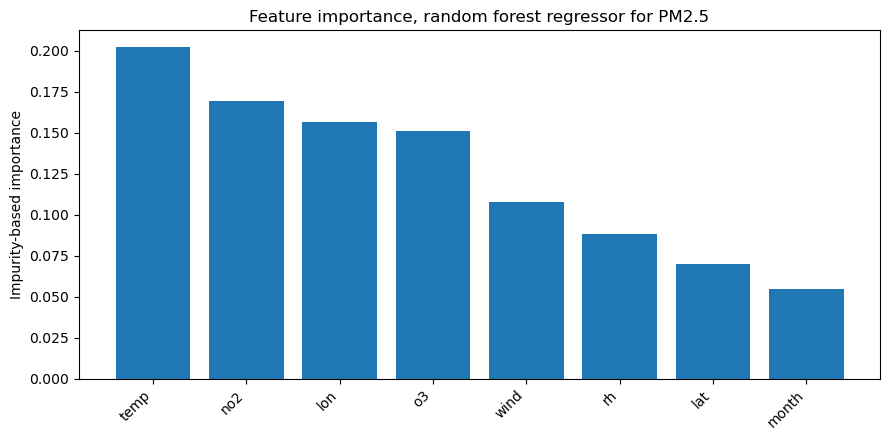

In [21]:
importances = rf_reg.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(importances)), importances[order])
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([featurenames[i] for i in order], rotation=45, ha="right")
ax.set_ylabel("Impurity-based importance")
ax.set_title("Feature importance, random forest regressor for PM2.5")
plt.tight_layout()
plt.show()

17. Which are the four most important features for predicting PM2.5? Print them with their importance values.

In [22]:
print("Four most important features for predicting PM2.5:")
print()
for rank, i in enumerate(order[:4], start=1):
    print(f"  {rank}. {featurenames[i]:<8} {importances[i]:.4f}  ({100 * importances[i]:.1f}%)")
print()
print(f"these four account for {100 * importances[order[:4]].sum():.1f}% of total importance")

# Two cautions on reading this chart.
#
# 1. Impurity-based importance is computed on the TRAINING data and is biased towards
#    high-cardinality continuous features. `month` is coarse (12 values) and will be
#    understated relative to its real influence; the continuous meteorological variables
#    will be overstated. Permutation importance on the validation set is the more
#    trustworthy measure when the ranking will inform a decision.
#
# 2. Importance is not causation, and it is not even a clean statement about information.
#    NO2 scores highly, but NO2 does not create PM2.5 in any direct sense -- both are
#    emitted by combustion and both accumulate under the same stagnant conditions. The
#    forest is using NO2 as a proxy for "urban emissions plus poor dispersion". That is
#    useful for prediction and misleading for policy: reducing NO2 would not mechanically
#    reduce PM2.5 by the amount this chart might suggest.

Four most important features for predicting PM2.5:

  1. temp     0.2025  (20.2%)
  2. no2      0.1693  (16.9%)
  3. lon      0.1564  (15.6%)
  4. o3       0.1511  (15.1%)

these four account for 67.9% of total importance


## Part 6: Interpretation

18. Your $R^2$ is likely to be far below what you might have expected, somewhere around
0.3–0.4 rather than the 0.9 that tutorial datasets tend to produce. This is the normal
situation for real environmental prediction, and it is worth understanding rather than
explaining away.

In three or four sentences, say what is **missing** from this feature set that would be
needed to predict PM2.5 well. Think about what actually determines the concentration of
particles over a county on a given day, and what none of these eight variables tells you
about.

**What is missing is almost everything that actually determines the particle burden over a
county on a given day.** The eight features describe the *dispersion* side of the problem
reasonably well and the *source* side barely at all.

Concretely, the largest omissions:

- **Emissions.** Nothing in the feature set says how much particulate matter was released.
  There is no traffic volume, no industrial activity, no residential wood burning, no
  agricultural burning, no construction. Two counties with identical weather and very
  different emissions have very different PM2.5, and the model has no way to tell them
  apart except through the crude proxies of latitude, longitude and NO2.
- **Transported smoke.** 2023 was the largest Canadian wildfire season on record, and the
  worst PM2.5 days in this dataset are smoke episodes over the eastern and midwestern US.
  The particles were emitted a thousand kilometres away and arrived on a synoptic-scale
  flow. Local temperature and wind speed carry essentially no information about whether a
  smoke plume is overhead. This single omission probably accounts for most of the model's
  failure on the extreme days seen in question 15.
- **Boundary layer depth.** The single most important meteorological control on surface
  concentrations is the depth of the layer the pollution is mixed through, which can vary by
  a factor of ten between a stable winter night and a convective summer afternoon. Surface
  temperature is a weak proxy for it; the actual quantity comes from a radiosonde or a
  reanalysis and is not here.
- **Wind direction**, as opposed to speed. Whether the wind is 10 knots from a city or 10
  knots from open ocean matters enormously, and speed alone cannot express it.
- **Precipitation.** Rain scavenges particles out of the atmosphere efficiently. A wet day
  is a clean day, and there is no precipitation variable in this dataset.
- **The previous day's concentration.** PM2.5 is highly autocorrelated. Simply knowing
  yesterday's value would probably outperform all eight of these features combined,
  as you will see directly in Assignment 8, where a persistence baseline is very strong.

An $R^2$ near 0.35 is therefore not a sign that the modelling was done badly. It is an
honest measurement of how much of the day-to-day variance in PM2.5 local meteorology and
co-pollutants can explain, which is a genuinely interesting scientific quantity. Reporting
it as such (rather than tuning hyperparameters until it looks better) is the correct
professional response.

19. Every split in this notebook was random, so days from July can land in the training set
while their immediate neighbours land in the test set. Given that PM2.5 is strongly
autocorrelated from day to day and strongly seasonal, what is wrong with that, and what
split would give a reliable estimate of how this model would perform if deployed to fill in
missing monitor data next year?

**A random split is dishonest here because the rows are not independent, and it is dishonest
in two distinct ways.**

**Temporal autocorrelation.** PM2.5 on consecutive days in the same county is highly
correlated: the same air mass, the same synoptic pattern, often the same pollution episode
persisting for several days. A random split scatters those neighbouring days across
training and test, so for almost every test row the model has already seen the day before
and the day after in the same county. It can effectively interpolate rather than predict.
This is exactly the mechanism Assignment 5 measured on hourly NOx, where it inflated the
apparent score substantially.

**Spatial replication.** The same problem operates across the county dimension. Every county
contributes many rows, so a random split puts most counties in both the training and the
test set. The model can learn "this particular county tends to run at 9 µg/m³" and score
well on held-out days from that same county, which is not the same as being able to say
anything about a county it has never seen.

**What an honest split looks like depends on the deployment you have in mind**, and the two
plausible ones need different designs:

- *Filling gaps in next year's record at monitored counties*, the use case the question
  describes. Split **chronologically**: train on the first part of the year, test on the
  last. Better still, train on 2023 and test on 2024, so the evaluation spans a different
  meteorological year entirely.
- *Estimating PM2.5 in a county with no monitor*, a common and more valuable application.
  Split **by county**, holding out entire counties, so no county appears in both sets.
  Expect the score to fall considerably, because the location features stop helping.

The general rule: the split has to break the same dependency that deployment will break. If
the model will meet genuinely new days, hold out days; if it will meet genuinely new places,
hold out places. Random splitting breaks neither and flatters the model on both counts.

20. `lat` and `lon` come out as useful features. Explain what the model is actually
learning from them, and give one reason this should make you cautious about applying the
fitted model to a county that was not in the training data.

**The model is using latitude and longitude as a lookup key for "which part of the country
is this, and what is its typical pollution level", not as physical variables.**

Latitude and longitude have no direct causal effect on particle concentrations. What they
encode is everything about a location that the other six features leave out: its emissions
inventory, its proximity to cities and highways and industry, its topography and whether it
sits in a valley that traps pollution, its typical synoptic weather, its regional
background. A tree splitting on longitude at −118° is effectively drawing a box around the
Los Angeles basin and learning the concentrations inside it. The features are standing in
for the missing emissions data identified in question 18.

**Why this should make you cautious about a new county:**

The most direct reason is that the model can only *interpolate* between locations it has
seen. A county in a region with no training data gets predictions assembled from whatever
counties happen to be nearest in coordinate space, and geographic proximity is a poor guide
to pollution similarity: a rural county twenty miles from a city has very different air, and
the model has no feature that distinguishes them.

Two further consequences worth stating:

- **The learned surface is discontinuous and arbitrary.** Trees split on axis-aligned
  thresholds, so the fitted spatial pattern is a patchwork of rectangles whose boundaries
  fall wherever the training counties happened to be. Those boundaries are artefacts of the
  sample, not features of the atmosphere, and a new county's prediction can depend on which
  side of a meaningless line it falls.
- **The sampling bias from question 1 propagates.** The merge retained mostly
  well-instrumented urban counties, so the coordinate-to-concentration mapping the model
  learned is an urban mapping. Applied to a rural county it will tend to over-predict.

The honest test is the county-held-out split described in question 19: hold out entire
counties and see how much the score falls. The size of that drop is a direct measurement of
how much of the model's apparent skill was location memorization rather than transferable
meteorological understanding. If you intend to predict at unmonitored locations, that number
is the only one worth quoting.